In [ ]:
from google.colab import files
uploaded = files.upload()

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load datasets
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submission = pd.read_csv('submission.csv')


In [8]:
# Trying to feature engineer to get the best results

# Converting date and time
if 'date' in df_train.columns:
    df_train['date'] = pd.to_datetime(df_train['date'])
    df_test['date'] = pd.to_datetime(df_test['date'])

    # Extract month, day of week, year
    df_train['month'] = df_train['date'].dt.month
    df_train['dayofweek'] = df_train['date'].dt.dayofweek
    df_train['year'] = df_train['date'].dt.year

    df_test['month'] = df_test['date'].dt.month
    df_test['dayofweek'] = df_test['date'].dt.dayofweek
    df_test['year'] = df_test['date'].dt.year

    # Flag weekends
    df_train['is_weekend'] = df_train['dayofweek'].isin([5,6]).astype(int)
    df_test['is_weekend'] = df_test['dayofweek'].isin([5,6]).astype(int)

    # Flag holiday months (Dec, Jan, Apr)
    holiday_months = [12, 1, 4]
    df_train['is_holiday_month'] = df_train['month'].isin(holiday_months).astype(int)
    df_test['is_holiday_month'] = df_test['month'].isin(holiday_months).astype(int)

    # Drop raw datetime column
    df_train = df_train.drop(columns=['date'])
    df_test = df_test.drop(columns=['date'])

if 'time' in df_train.columns:
    df_train['hour'] = pd.to_datetime(df_train['time']).dt.hour
    df_test['hour'] = pd.to_datetime(df_test['time']).dt.hour
    df_train = df_train.drop(columns=['time'])
    df_test = df_test.drop(columns=['time'])

/tmp/ipykernel_190/981133141.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['hour'] = pd.to_datetime(df_train['time']).dt.hour
/tmp/ipykernel_190/981133141.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['hour'] = pd.to_datetime(df_test['time']).dt.hour


In [9]:
# Member customers
if 'customer_type' in df_train.columns:
    df_train['is_member'] = (df_train['customer_type'] == 'Member').astype(int)
    df_test['is_member'] = (df_test['customer_type'] == 'Member').astype(int)
    df_train = df_train.drop(columns=['customer_type'])
    df_test = df_test.drop(columns=['customer_type'])

# Discounts effect
if 'discount_pct' in df_train.columns and 'quantity' in df_train.columns:
    df_train['discount_effect'] = df_train['discount_pct'] * df_train['quantity']
    df_test['discount_effect'] = df_test['discount_pct'] * df_test['quantity']

# Store type one-hot encoding
if 'store_type' in df_train.columns:
    df_train = pd.get_dummies(df_train, columns=['store_type'])
    df_test = pd.get_dummies(df_test, columns=['store_type'])

# Store + Product combination
if 'store_id' in df_train.columns and 'product_id' in df_train.columns:
    df_train['store_product'] = df_train['store_id'].astype(str) + "_" + df_train['product_id'].astype(str)
    df_test['store_product'] = df_test['store_id'].astype(str) + "_" + df_test['product_id'].astype(str)
    df_train = pd.get_dummies(df_train, columns=['store_product'])
    df_test = pd.get_dummies(df_test, columns=['store_product'])


RMSE: 194.5846697930266


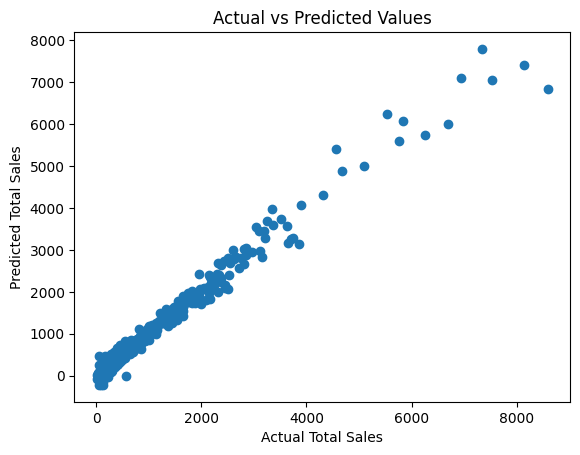

In [10]:
# Training the model
# Separate features and target
x = df_train.drop(columns=['total_sales'])
y = df_train['total_sales']

# Handle categorical variables
x = pd.get_dummies(x)
test = pd.get_dummies(df_test)

# Align train and test columns
x, test = x.align(test, join='left', axis=1, fill_value=0)

# Train Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(x, y)

# Evaluate model
y_pred = model.predict(x)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

# Scatter Plot
plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted Values")
plt.show()


In [11]:
# Prediction on Test Data
test_preds = model.predict(test)

# Prepare submission
submit = df_submission.copy()
submit['total_sales'] = test_preds
submit.to_csv('submit.csv', index=False)

from google.colab import files
files.download('submit.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>